In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("data/education.db")

In [ ]:
primary = pd.read_sql("SELECT * FROM primary_gender_merged", conn)
secondary = pd.read_sql("SELECT * FROM secondary_gender_merged", conn)
tertiary = pd.read_sql("SELECT * FROM tertiary_gender_merged", conn)

In [3]:
primary["level"] = "primary"
secondary["level"] = "secondary"
tertiary["level"] = "tertiary"

## SQL EDA

In [33]:
df_total = pd.concat([primary, secondary, tertiary], ignore_index=True)
df_total.to_sql(
    "all_enrollment",
    conn,
    if_exists="replace",
    index=False
)
df_total["gender_gap"] = df_total["female"] - df_total["male"]

In [ ]:
# Average male and female enrollment by level
pd.read_sql("""
SELECT level,
       AVG(male) AS avg_male,
       AVG(female) AS avg_female
FROM all_enrollment
GROUP BY level;
""", conn)

,level,avg_male,avg_female
0,primary,101.452112,98.446556
1,secondary,75.209767,72.987773
2,tertiary,34.912865,41.565356


In [ ]:
# Gender gap by level
pd.read_sql("""
SELECT level,
       AVG(female - male) AS gender_gap
FROM all_enrollment
GROUP BY level;
""", conn)

,level,gender_gap
0,primary,-3.005555
1,secondary,-2.221994
2,tertiary,6.652490


In [ ]:
# Gender Gap by Region
pd.read_sql("""
SELECT country_code,
       level,
       AVG(female - male) AS gender_gap
FROM all_enrollment
GROUP BY country_code, level
ORDER BY gender_gap DESC;
""", conn)

,country_code,level,gender_gap
0,AUS,tertiary,39.740521
1,NAC,tertiary,26.915088
2,HIC,tertiary,16.021924
3,EUU,tertiary,13.890749
4,LCN,tertiary,10.977901
5,LCN,secondary,5.691703
6,UMC,tertiary,5.333504
7,EAS,tertiary,3.066817
8,UMC,secondary,1.973275
9,ARB,tertiary,1.647031


In [ ]:
# Primary Enrollment Percentage Change from 2000 to 2023
pd.read_sql("""
SELECT
    country_code,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN male END) -
         MAX(CASE WHEN year = '2000' THEN male END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN male END), 2
    ) AS male_pct_change,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN female END) -
         MAX(CASE WHEN year = '2000' THEN female END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN female END), 2
    ) AS female_pct_change

FROM all_enrollment
WHERE level = 'primary'
GROUP BY country_code
ORDER BY female_pct_change DESC;
""", conn)


,country_code,male_pct_change,female_pct_change
0,UMC,273.87,365.86
1,SAS,187.65,359.01
2,EAS,223.25,337.83
3,LMC,136.49,227.91
4,LCN,130.50,176.33
5,ARB,81.66,115.19
6,EUU,47.48,64.44
7,HIC,37.07,49.83
8,NAC,17.52,27.16
9,LIC,NaN,NaN


In [59]:
# Secondary Enrollment Percentage Change from 2000 to 2023
pd.read_sql("""
SELECT
    country_code,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN male END) -
         MAX(CASE WHEN year = '2000' THEN male END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN male END), 2
    ) AS male_pct_change,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN female END) -
         MAX(CASE WHEN year = '2000' THEN female END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN female END), 2
    ) AS female_pct_change

FROM all_enrollment
WHERE level = 'secondary'
GROUP BY country_code
ORDER BY female_pct_change DESC;
""", conn)

,country_code,male_pct_change,female_pct_change
0,AFW,81.01,145.51
1,SAS,43.33,93.69
2,LMC,39.41,73.88
3,EAS,44.34,52.12
4,UMC,39.71,46.59
5,LCN,22.91,22.92
6,ARB,12.15,20.43
7,EUU,5.37,5.36
8,HIC,5.39,3.74
9,NAC,4.51,1.77


In [60]:
# Tertiary Enrollment Percentage Change from 2000 to 2023
pd.read_sql("""
SELECT
    country_code,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN male END) -
         MAX(CASE WHEN year = '2000' THEN male END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN male END), 2
    ) AS male_pct_change,

    ROUND(
        (MAX(CASE WHEN year = '2023' THEN female END) -
         MAX(CASE WHEN year = '2000' THEN female END)) * 100.0 /
         MAX(CASE WHEN year = '2000' THEN female END), 2
    ) AS female_pct_change

FROM all_enrollment
WHERE level = 'tertiary'
GROUP BY country_code
ORDER BY female_pct_change DESC;
""", conn)

,country_code,male_pct_change,female_pct_change
0,UMC,273.87,365.86
1,SAS,187.65,359.01
2,EAS,223.25,337.83
3,LMC,136.49,227.91
4,LCN,130.50,176.33
5,ARB,81.66,115.19
6,EUU,47.48,64.44
7,HIC,37.07,49.83
8,NAC,17.52,27.16
9,LIC,NaN,NaN


In [4]:
primary = primary.rename(columns={
    "male_enrollment": "male",
    "female_enrollment": "female"
})

secondary = secondary.rename(columns={
    "male_enrollment": "male",
    "female_enrollment": "female"
})

tertiary = tertiary.rename(columns={
    "male_enrollment": "male",
    "female_enrollment": "female"
})

In [6]:
df_total = pd.concat([primary, secondary, tertiary], ignore_index=True)

In [7]:
df_total.to_csv("data/cleaned/all_enrollment_combined.csv", index=False)

In [ ]:
df_total["gender_gap"] = df_total["female"] - df_total["male"]

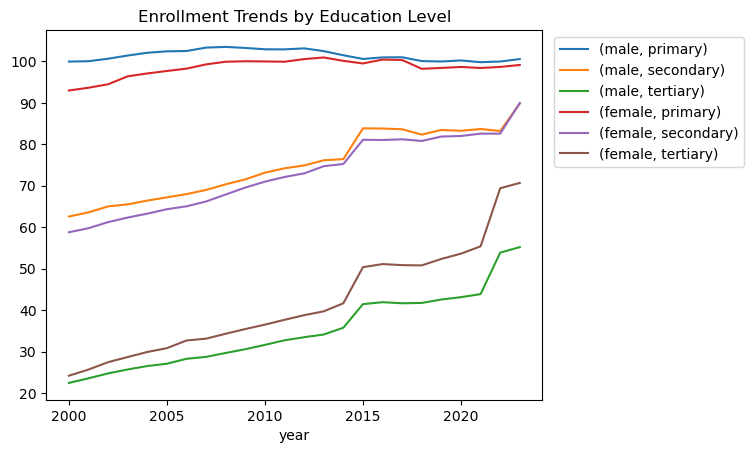

In [ ]:
# Enrollment Trends
ax = df_total.groupby(["year","level"])[["male","female"]].mean().unstack().plot()

plt.title("Enrollment Trends by Education Level")

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.show()

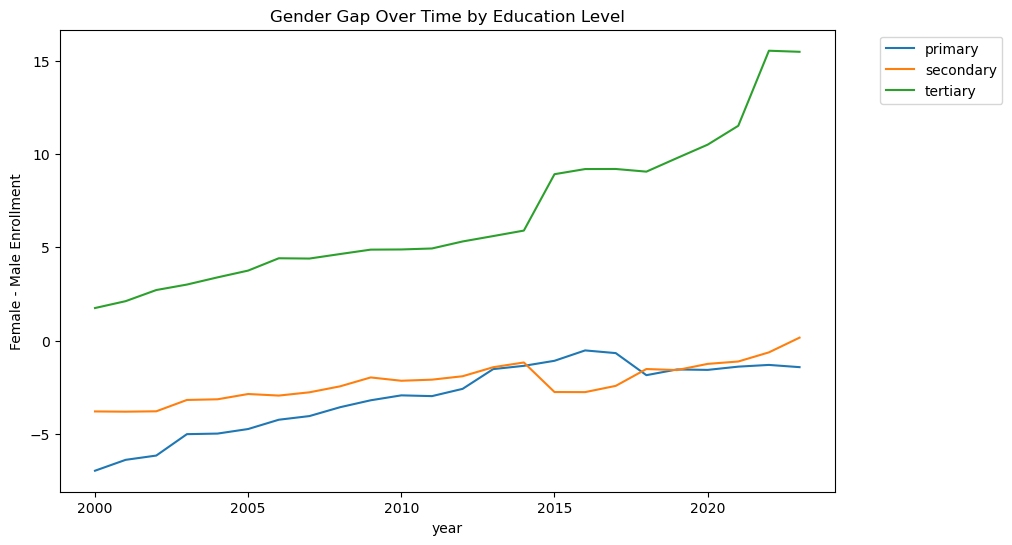

In [ ]:
# Gender gap between male and female enrollment

df_total["gender_gap"] = df_total["female"] - df_total["male"]

ax = df_total.groupby(["year","level"])["gender_gap"].mean().unstack().plot(figsize=(10,6))

plt.title("Gender Gap Over Time by Education Level")
plt.ylabel("Female - Male Enrollment")

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

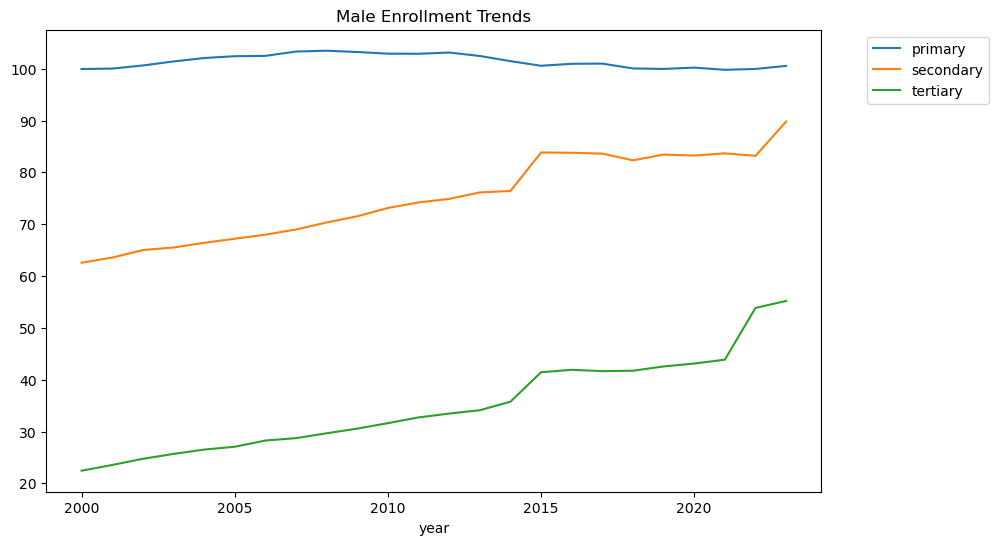

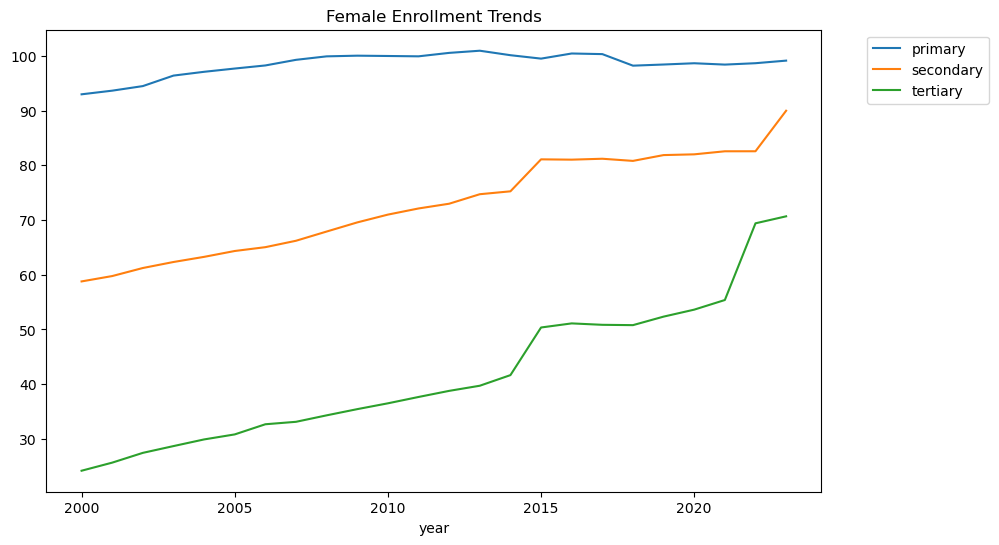

In [22]:

# Male Enrollment Trends
ax = df_total.groupby(["year","level"])["male"].mean().unstack().plot(figsize=(10,6))
plt.title("Male Enrollment Trends")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Femmale Enrollment Trends
ax = df_total.groupby(["year","level"])["female"].mean().unstack().plot(figsize=(10,6))
plt.title("Female Enrollment Trends")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

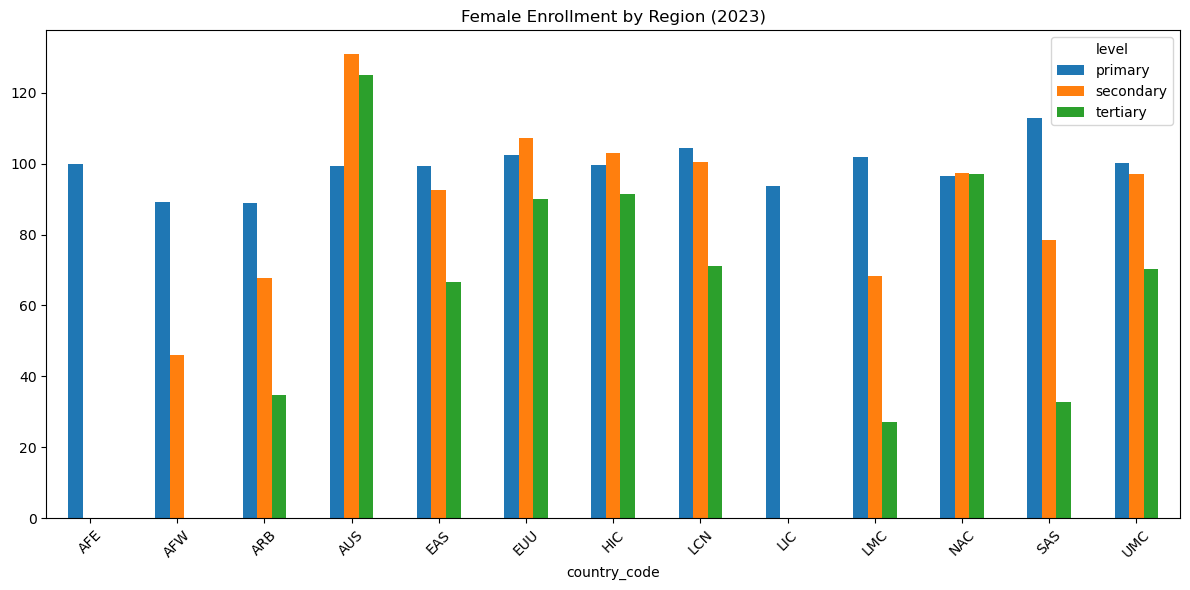

In [23]:
pivot = df_total[df_total["year"] == "2023"].pivot_table(
    index="country_code",
    columns="level",
    values="female"
)

pivot.plot(kind="bar", figsize=(12,6))

plt.title("Female Enrollment by Region (2023)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

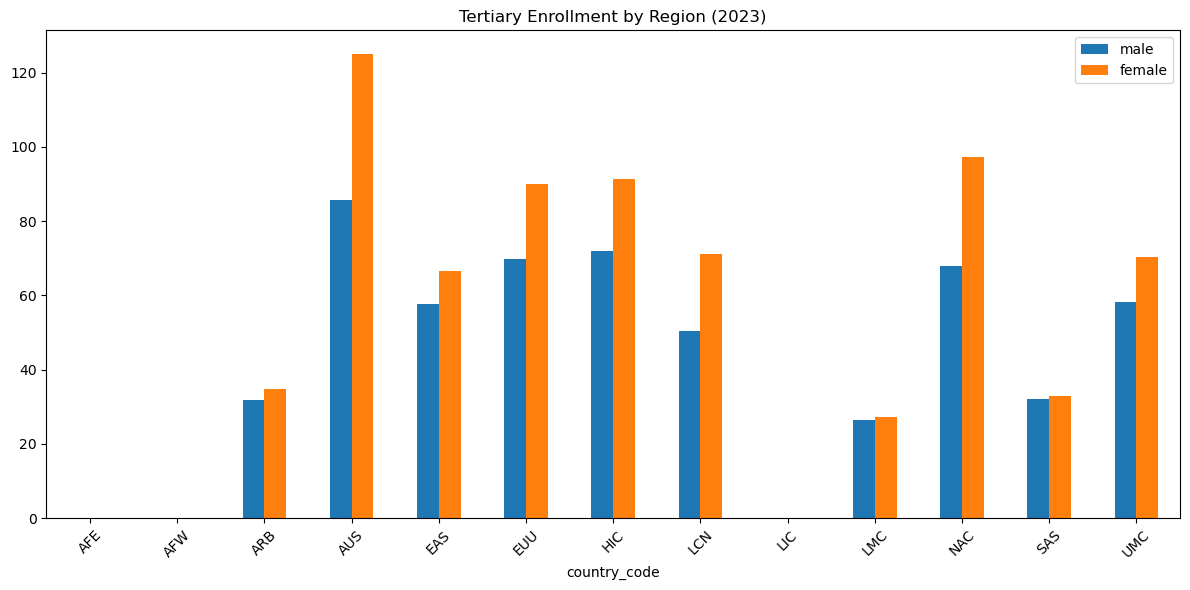

In [28]:
tertiary_2023 = latest[latest["level"] == "tertiary"]

tertiary_2023.set_index("country_code")[["male","female"]].plot(
    kind="bar", figsize=(12,6)
)

plt.title("Tertiary Enrollment by Region (2023)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()